# Negative Reason Detector - Error Analysis


## 1. Setup and paths


In [1]:
from pathlib import Path
from collections import Counter

import ast
import json
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_columns", 50)

RESULTS_PATH = Path("../reports/negative_reason_detection/negative_reason_detection.csv")
SENTIMENT_TRAIN_PATH = Path("../data/processed/train.csv")

REPORTS_DIR = Path("../reports/negative_reason_detection")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Results path:", RESULTS_PATH)
print("Sentiment train path:", SENTIMENT_TRAIN_PATH)


Results path: ../reports/negative_reason_detection/negative_reason_detection.csv
Sentiment train path: ../data/processed/train.csv


## 2. Load detector results


In [2]:
df = pd.read_csv(RESULTS_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.columns.to_frame(index=False, name="columns"))


Shape: (4000, 11)


,source_row,text,labels,labels_pipe,has_multiple_reasons,sentence_count,reason_scores,heuristic_confidence,supporting_sentences,matched_patterns,reasons
0,0,"I was seriously looking forward to seeing this film because it seemed truly promising from the coming attractions: Jim Carrey with Godlike powers was an idea that most definitely worked for me. As a huge fan, I was s...","[""weak_plot_bad_writing"", ""failed_expectations"", ""not_funny"", ""poor_direction_execution""]",weak_plot_bad_writing|failed_expectations|not_funny|poor_direction_execution,True,32,"{""weak_plot_bad_writing"": 6.5, ""failed_expectations"": 4.0, ""not_funny"": 1.7, ""poor_direction_execution"": 1.0}","{""weak_plot_bad_writing"": 1.0, ""failed_expectations"": 1.0, ""not_funny"": 0.425, ""poor_direction_execution"": 0.25}","{""weak_plot_bad_writing"": [""She wants him to marry her, see, so she winds up leaving him, see, even though she still LOVES him very much, see, and the rest of the film is spent banging us over the head with one pathe...","{""weak_plot_bad_writing"": [""\\bbeyond-?heavy-?handed\\b"", ""\\bheavy-?handed\\b"", ""\\bcliche(?:d|s)?\\b"", ""\\bwriters? lose track\\b"", ""\\bno idea how to resolve\\b""], ""failed_expectations"": [""\\b(?:really )?looking f...","{""weak_plot_bad_writing"": {""label"": ""weak_plot_bad_writing"", ""score"": 6.5, ""heuristic_confidence"": 1.0, ""confidence"": 1.0, ""evidence_count"": 6, ""explicit_evidence_count"": 6, ""weak_evidence_count"": 0, ""supporting_sent..."
1,3,"I love science fiction, I am fascinated by Egyptian mythology and I appreciate digital animation. I figured a movie that combines these three would be at least enjoyable. I could not have been more wrong: The story (...","[""bad_acting"", ""poor_visuals_effects"", ""bad_dialogue"", ""weak_plot_bad_writing"", ""poor_direction_execution""]",bad_acting|poor_visuals_effects|bad_dialogue|weak_plot_bad_writing|poor_direction_execution,True,14,"{""bad_acting"": 4.5, ""poor_visuals_effects"": 4.4, ""bad_dialogue"": 2.7, ""weak_plot_bad_writing"": 2.1, ""poor_direction_execution"": 1.2}","{""bad_acting"": 1.0, ""poor_visuals_effects"": 1.0, ""bad_dialogue"": 0.675, ""weak_plot_bad_writing"": 0.525, ""poor_direction_execution"": 0.3}","{""bad_acting"": [""The dialogue and acting are even worse than in an average porno movie."", ""Bad acting would not have been such a huge problem if only 'director' Bilal did not take himself so seriously""], ""poor_visual...","{""bad_acting"": [""\\bacting (?:was|is|were|are|felt|seemed) (?:even )?(?:bad|awful|terrible|horrendous|poor|weak|flat|wooden|unconvincing|worse)\\b"", ""\\bdialogue and acting (?:were|are|was|is) (?:even )?worse\\b"", ""\...","{""bad_acting"": {""label"": ""bad_acting"", ""score"": 4.5, ""heuristic_confidence"": 1.0, ""confidence"": 1.0, ""evidence_count"": 3, ""explicit_evidence_count"": 3, ""weak_evidence_count"": 0, ""supporting_sentences"": [""The dialogue..."
2,7,"Given the title and outlandish box art, I was ready for just about anything. Perhaps my expectation were forced just a bit to high, because I was left a little dry. A film crew working on a soft-core sex movie end u...","[""tonal_mismatch"", ""failed_expectations"", ""generic_unoriginal""]",tonal_mismatch|failed_expectations|generic_unoriginal,True,14,"{""tonal_mismatch"": 2.4, ""failed_expectations"": 1.1, ""generic_unoriginal"": 1.0}","{""tonal_mismatch"": 0.6, ""failed_expectations"": 0.275, ""generic_unoriginal"": 0.25}","{""tonal_mismatch"": [""it's too over-sexed to be a strait horror picture and too gruesome to work as a sex flick.""], ""failed_expectations"": [""Perhaps my expectation were forced just a bit to high, because I was left a ...","{""tonal_mismatch"": [""\\btoo gruesome to work as (?:a |an )?sex flick\\b"", ""\\btoo gruesome to work\\b""], ""failed_expectations"": [""\\bleft a little dry\\b""], ""generic_unoriginal"": [""\\bstandard fare\\b""]}","{""tonal_mismatch"": {""label"": ""tonal_mismatch"", ""score"":

,columns
0,source_row
1,text
2,labels
3,labels_pipe
4,has_multiple_reasons
5,sentence_count
6,reason_scores
7,heuristic_confidence
8,supporting_sentences
9,matched_patterns


In [3]:
required_columns = {"text", "labels_pipe"}

missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in detector output: {missing_columns}")

df["labels_pipe"] = df["labels_pipe"].fillna("other_uncertain").astype(str)
df["text"] = df["text"].fillna("").astype(str)

if "source_row" not in df.columns:
    df["source_row"] = df.index

df.head(2)


,source_row,text,labels,labels_pipe,has_multiple_reasons,sentence_count,reason_scores,heuristic_confidence,supporting_sentences,matched_patterns,reasons
0,0,"I was seriously looking forward to seeing this film because it seemed truly promising from the coming attractions: Jim Carrey with Godlike powers was an idea that most definitely worked for me. As a huge fan, I was s...","[""weak_plot_bad_writing"", ""failed_expectations"", ""not_funny"", ""poor_direction_execution""]",weak_plot_bad_writing|failed_expectations|not_funny|poor_direction_execution,True,32,"{""weak_plot_bad_writing"": 6.5, ""failed_expectations"": 4.0, ""not_funny"": 1.7, ""poor_direction_execution"": 1.0}","{""weak_plot_bad_writing"": 1.0, ""failed_expectations"": 1.0, ""not_funny"": 0.425, ""poor_direction_execution"": 0.25}","{""weak_plot_bad_writing"": [""She wants him to marry her, see, so she winds up leaving him, see, even though she still LOVES him very much, see, and the rest of the film is spent banging us over the head with one pathe...","{""weak_plot_bad_writing"": [""\\bbeyond-?heavy-?handed\\b"", ""\\bheavy-?handed\\b"", ""\\bcliche(?:d|s)?\\b"", ""\\bwriters? lose track\\b"", ""\\bno idea how to resolve\\b""], ""failed_expectations"": [""\\b(?:really )?looking f...","{""weak_plot_bad_writing"": {""label"": ""weak_plot_bad_writing"", ""score"": 6.5, ""heuristic_confidence"": 1.0, ""confidence"": 1.0, ""evidence_count"": 6, ""explicit_evidence_count"": 6, ""weak_evidence_count"": 0, ""supporting_sent..."
1,3,"I love science fiction, I am fascinated by Egyptian mythology and I appreciate digital animation. I figured a movie that combines these three would be at least enjoyable. I could not have been more wrong: The story (...","[""bad_acting"", ""poor_visuals_effects"", ""bad_dialogue"", ""weak_plot_bad_writing"", ""poor_direction_execution""]",bad_acting|poor_visuals_effects|bad_dialogue|weak_plot_bad_writing|poor_direction_execution,True,14,"{""bad_acting"": 4.5, ""poor_visuals_effects"": 4.4, ""bad_dialogue"": 2.7, ""weak_plot_bad_writing"": 2.1, ""poor_direction_execution"": 1.2}","{""bad_acting"": 1.0, ""poor_visuals_effects"": 1.0, ""bad_dialogue"": 0.675, ""weak_plot_bad_writing"": 0.525, ""poor_direction_execution"": 0.3}","{""bad_acting"": [""The dialogue and acting are even worse than in an average porno movie."", ""Bad acting would not have been such a huge problem if only 'director' Bilal did not take himself so seriously""], ""poor_visual...","{""bad_acting"": [""\\bacting (?:was|is|were|are|felt|seemed) (?:even )?(?:bad|awful|terrible|horrendous|poor|weak|flat|wooden|unconvincing|worse)\\b"", ""\\bdialogue and acting (?:were|are|was|is) (?:even )?worse\\b"", ""\...","{""bad_acting"": {""label"": ""bad_acting"", ""score"": 4.5, ""heuristic_confidence"": 1.0, ""confidence"": 1.0, ""evidence_count"": 3, ""explicit_evidence_count"": 3, ""weak_evidence_count"": 0, ""supporting_sentences"": [""The dialogue..."


## 3. Review-level `other_uncertain` rate


In [4]:
total_reviews = len(df)
other_reviews = (df["labels_pipe"] == "other_uncertain").sum()
labeled_reviews = total_reviews - other_reviews

other_rate = other_reviews / total_reviews if total_reviews else 0
labeled_rate = labeled_reviews / total_reviews if total_reviews else 0

summary = pd.DataFrame({
    "metric": [
        "total_reviews",
        "reviews_with_detected_reason",
        "other_uncertain_reviews",
        "detected_reason_rate",
        "other_uncertain_rate",
    ],
    "value": [
        total_reviews,
        labeled_reviews,
        other_reviews,
        labeled_rate,
        other_rate,
    ],
})

display(summary)

print(f"Total reviews: {total_reviews}")
print(f"Reviews with at least one detected reason: {labeled_reviews} ({labeled_rate:.2%})")
print(f"other_uncertain reviews: {other_reviews} ({other_rate:.2%})")


,metric,value
0,total_reviews,4000.0000
1,reviews_with_detected_reason,1682.0000
2,other_uncertain_reviews,2318.0000
3,detected_reason_rate,0.4205
4,other_uncertain_rate,0.5795


Total reviews: 4000
Reviews with at least one detected reason: 1682 (42.05%)
other_uncertain reviews: 2318 (57.95%)


In [5]:
coverage_summary_path = REPORTS_DIR / "coverage_summary.csv"
summary.to_csv(coverage_summary_path, index=False)
coverage_summary_path


PosixPath('../reports/negative_reason_detection/coverage_summary.csv')

## 4. Label distribution


In [6]:
label_counter = Counter()

for labels in df["labels_pipe"]:
    for label in str(labels).split("|"):
        label = label.strip()
        if label:
            label_counter[label] += 1

label_counts = (
    pd.DataFrame(label_counter.items(), columns=["label", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

label_counts["share_of_reviews"] = label_counts["count"] / total_reviews

display(label_counts)

label_counts_path = REPORTS_DIR / "label_counts.csv"
label_counts.to_csv(label_counts_path, index=False)
label_counts_path


,label,count,share_of_reviews
0,other_uncertain,2318,0.57950
1,boring_slow_pacing,545,0.13625
2,weak_plot_bad_writing,372,0.09300
3,bad_acting,276,0.06900
4,poor_production_quality,252,0.06300
5,failed_expectations,217,0.05425
6,not_funny,169,0.04225
7,generic_unoriginal,127,0.03175
8,weak_characters,115,0.02875
9,confusing_story,86,0.02150


PosixPath('../reports/negative_reason_detection/label_counts.csv')

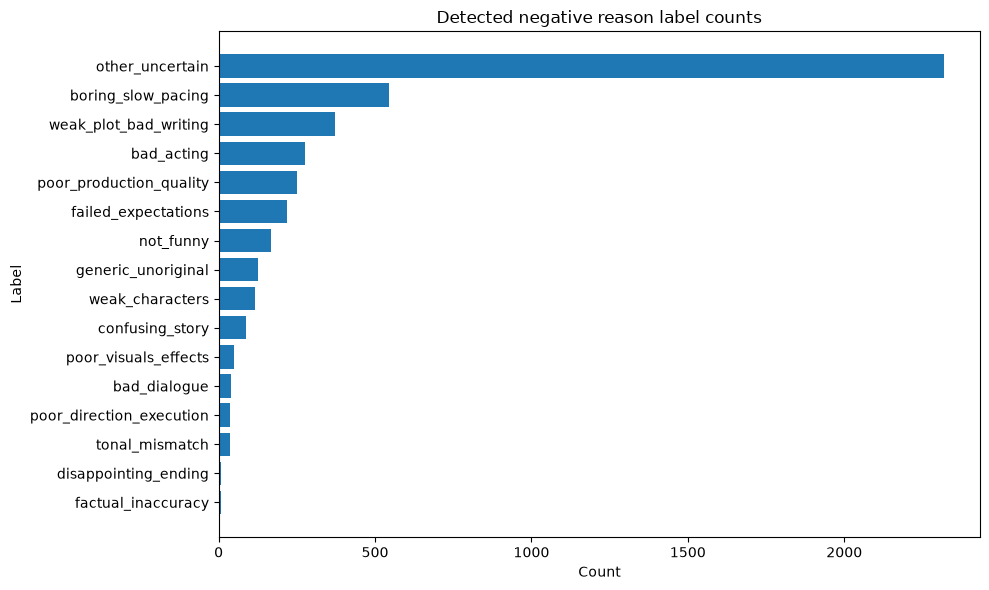

In [7]:
plot_df = label_counts.sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["count"])
plt.title("Detected negative reason label counts")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()


## 5. Multi-label behavior


,num_detected_reason_labels,review_count,share
0,0,2318,0.57950
1,1,1168,0.29200
2,2,403,0.10075
3,3,85,0.02125
4,4,21,0.00525
5,5,5,0.00125


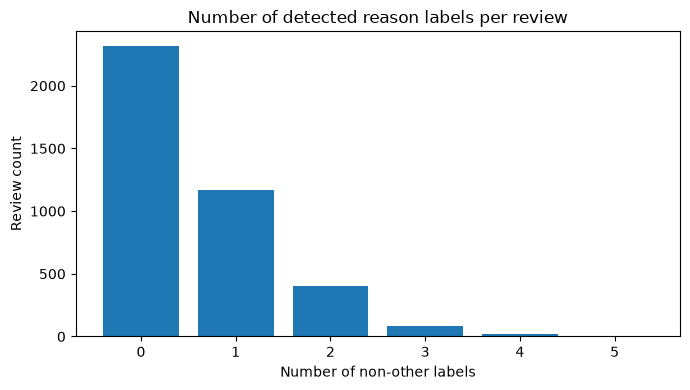

In [8]:
def split_labels(labels_pipe: str) -> list[str]:
    labels = [label.strip() for label in str(labels_pipe).split("|") if label.strip()]
    return labels

df["label_list"] = df["labels_pipe"].apply(split_labels)
df["num_labels"] = df["label_list"].apply(lambda labels: 0 if labels == ["other_uncertain"] else len(labels))
df["has_detected_reason"] = df["labels_pipe"] != "other_uncertain"

multi_summary = df["num_labels"].value_counts().sort_index().rename_axis("num_detected_reason_labels").reset_index(name="review_count")
multi_summary["share"] = multi_summary["review_count"] / len(df)

display(multi_summary)

plt.figure(figsize=(7, 4))
plt.bar(multi_summary["num_detected_reason_labels"].astype(str), multi_summary["review_count"])
plt.title("Number of detected reason labels per review")
plt.xlabel("Number of non-other labels")
plt.ylabel("Review count")
plt.tight_layout()
plt.show()


## 6. Manual inspection samples


In [9]:
other_df = df[df["labels_pipe"] == "other_uncertain"].copy()
labeled_df = df[df["labels_pipe"] != "other_uncertain"].copy()

sample_other = other_df.sample(min(100, len(other_df)), random_state=42)
sample_labeled = labeled_df.sample(min(100, len(labeled_df)), random_state=42)

other_sample_path = REPORTS_DIR / "manual_inspection_other_uncertain_100.csv"
labeled_sample_path = REPORTS_DIR / "manual_inspection_labeled_100.csv"

sample_other[["source_row", "text", "labels_pipe"]].to_csv(other_sample_path, index=False)
sample_labeled[["source_row", "text", "labels_pipe"]].to_csv(labeled_sample_path, index=False)

print("Saved:", other_sample_path)
print("Saved:", labeled_sample_path)

display(sample_other[["source_row", "text", "labels_pipe"]].head(10))


Saved: ../reports/negative_reason_detection/manual_inspection_other_uncertain_100.csv
Saved: ../reports/negative_reason_detection/manual_inspection_labeled_100.csv


,source_row,text,labels_pipe
1807,3650,"I don't know about you, but what I love about Tom and Jerry cartoons is the (often violent) interaction between the two characters. Mouse In Manhattan sees Jerry leaving Tom behind to have an adventure in New York, a...",other_uncertain
942,1940,"I saw this feature as part of the Asian American Film Festival in New York and was horrified by the graphic, sado-masochistic, child pornography that I witnessed. The story line is hidden beneath way too many graphic...",other_uncertain
187,394,"A dedicated fan to the TLK movies, with the first one being a milestone and the second probably the best sequel Disney has produced, along comes this film... Now I'm not arguing with animation, voice work, music, but...",other_uncertain
1814,3664,"So much is wrong with this abysmal little wet fart of a movie that it's hard to know where to begin. First of all, it's a remarkably un-scary scary movie, even by Amercian standards. The dialogue is cliché, the char...",other_uncertain
429,859,"Not the best of the films to be watched nowadays. I read a lot of reviews about Shining and was expecting it to be very good. But this movie disappointed me. The sound and environment was good, but there was no story...",other_uncertain
816,1699,"I remembered the title so well. To me, it was a Flora Robson movie with Olivier and Vivien Leigh in supporting roles. And it had Vincent Massey's voice from behind whiskers. Well Flora Robson was great. Her next sign...",other_uncertain
2714,5417,"I only gave this ridiculously titled comedy horror flick a 2 because several famous porn stars of the past appear in it. A group of tourists, supposedly on vacation in Ireland but actually in Canada, run afoul of a c...",other_uncertain
3613,7185,"...Ok I have read about this film somewhere in the internet, and many criticized on how bad and sucks this film was. And I couldn't have been more agree about it. Then after that I saw this film on DVD, I was thinkin...",other_uncertain
327,659,"The box for ""To Die For"" suckered me in -- a shirtless hunky guy and the promise of some laughs and sex. There was plenty of Thomas Arklie (Simon), who's easy on the eyes, but no laughs and little sexiness. The coup...",other_uncertain
2820,5636,"Ivan (Valeri Nikolayev) is a bitter, cynical journalist who investigates the unexplained. He travels to this small town where it's said that a witch (Ita Ever) is terrorizing the community. His car stalls and he tak...",other_uncertain


## 7. Frequent n-grams in `other_uncertain`


In [10]:
CUSTOM_STOPWORDS = {
    "don", "didn", "doesn", "isn", "wasn", "weren", "wouldn", "couldn", "shouldn",
    "ve", "ll", "re", "d", "m", "s", "t",
    "br", "movie", "film", "movies", "films"
}

STOP_WORDS = list(ENGLISH_STOP_WORDS.union(CUSTOM_STOPWORDS))

def top_ngrams(
    texts,
    ngram_range=(2, 5),
    min_df=5,
    max_df=0.5,
    top_n=100,
):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        stop_words=STOP_WORDS,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
        lowercase=True,
    )

    X = vectorizer.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    phrases = np.array(vectorizer.get_feature_names_out())

    top_idx = np.argsort(counts)[-top_n:][::-1]

    return pd.DataFrame({
        "phrase": phrases[top_idx],
        "count": counts[top_idx],
    })

top_other_ngrams = top_ngrams(
    other_df["text"],
    ngram_range=(2, 5),
    min_df=5,
    max_df=0.5,
    top_n=100,
)

display(top_other_ngrams.head(50))

top_other_ngrams_path = REPORTS_DIR / "top_other_uncertain_ngrams.csv"
top_other_ngrams.to_csv(top_other_ngrams_path, index=False)
top_other_ngrams_path


,phrase,count
0,i've seen,183
1,don't know,126
2,looks like,105
3,special effects,100
4,i'm sure,89
5,it's just,85
6,year old,78
7,look like,76
8,don't think,67
9,pretty good,55


PosixPath('../reports/negative_reason_detection/top_other_uncertain_ngrams.csv')

## 8. Frequent n-grams in detected reviews


In [11]:
top_labeled_ngrams = top_ngrams(
    labeled_df["text"],
    ngram_range=(2, 5),
    min_df=5,
    max_df=0.5,
    top_n=100,
)

display(top_labeled_ngrams.head(50))

top_labeled_ngrams_path = REPORTS_DIR / "top_labeled_ngrams.csv"
top_labeled_ngrams.to_csv(top_labeled_ngrams_path, index=False)
top_labeled_ngrams_path


,phrase,count
0,waste time,243
1,low budget,192
2,i've seen,162
3,special effects,133
4,bad acting,100
5,looks like,99
6,don't know,85
7,don't waste,85
8,it's just,81
9,i'm sure,74


PosixPath('../reports/negative_reason_detection/top_labeled_ngrams.csv')

## 9. TF-IDF: `other_uncertain` vs detected reason


In [12]:
df["is_other_uncertain"] = (df["labels_pipe"] == "other_uncertain").astype(int)

other_vs_detected_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(2, 5),
        min_df=5,
        max_df=0.5,
        stop_words=STOP_WORDS,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
        lowercase=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
    ))
])

other_vs_detected_pipeline.fit(df["text"], df["is_other_uncertain"])

pred = other_vs_detected_pipeline.predict(df["text"])
print(classification_report(df["is_other_uncertain"], pred, target_names=["detected_reason", "other_uncertain"]))
print(confusion_matrix(df["is_other_uncertain"], pred))


                 precision    recall  f1-score   support

detected_reason       0.93      0.85      0.89      1682
other_uncertain       0.90      0.95      0.92      2318

       accuracy                           0.91      4000
      macro avg       0.91      0.90      0.91      4000
   weighted avg       0.91      0.91      0.91      4000

[[1432  250]
 [ 109 2209]]


In [13]:
vectorizer = other_vs_detected_pipeline.named_steps["tfidf"]
clf = other_vs_detected_pipeline.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]

top_other_idx = np.argsort(coefs)[-100:][::-1]
top_detected_idx = np.argsort(coefs)[:100]

top_other_phrases = pd.DataFrame({
    "phrase": feature_names[top_other_idx],
    "coefficient": coefs[top_other_idx],
})

top_detected_phrases = pd.DataFrame({
    "phrase": feature_names[top_detected_idx],
    "coefficient": coefs[top_detected_idx],
})

display(top_other_phrases.head(50))
display(top_detected_phrases.head(30))

top_other_phrases.to_csv(REPORTS_DIR / "feature_importance_other_uncertain_vs_detected__other_phrases.csv", index=False)
top_detected_phrases.to_csv(REPORTS_DIR / "feature_importance_other_uncertain_vs_detected__detected_phrases.csv", index=False)


,phrase,coefficient
0,highly recommend,1.065319
1,like little,0.933165
2,haven't seen,0.893809
3,comic relief,0.859954
4,just did,0.853985
5,really good,0.843543
6,civil war,0.839791
7,isn't just,0.794500
8,linda blair,0.754981
9,doesn't look,0.733222


,phrase,coefficient
0,low budget,-6.644353
1,waste time,-6.126747
2,bad acting,-4.214162
3,camera work,-3.321260
4,fell asleep,-2.843482
5,looking forward,-2.684821
6,fast forward,-2.571640
7,acting poor,-2.323190
8,poor acting,-2.018948
9,acting bad,-1.934703


## 10. Candidate phrase extraction from `other_uncertain`


In [14]:
candidate_phrases = (
    top_other_ngrams
    .merge(top_other_phrases, on="phrase", how="left")
    .fillna({"coefficient": 0.0})
)

candidate_phrases["candidate_score"] = candidate_phrases["count"] * candidate_phrases["coefficient"].clip(lower=0)

candidate_phrases = candidate_phrases.sort_values(
    ["candidate_score", "count"],
    ascending=False
).reset_index(drop=True)

display(candidate_phrases.head(75))

candidate_path = REPORTS_DIR / "candidate_missing_patterns_from_other_uncertain.csv"
candidate_phrases.to_csv(candidate_path, index=False)
candidate_path


,phrase,count,coefficient,candidate_score
0,don't know,126,0.542192,68.316151
1,look like,76,0.724418,55.055777
2,really good,40,0.843543,33.741733
3,haven't seen,37,0.893809,33.070927
4,comic relief,20,0.859954,17.199085
...,...,...,...,...
70,like it's,24,0.000000,0.000000
71,didn't like,24,0.000000,0.000000
72,really really,24,0.000000,0.000000
73,supporting cast,24,0.000000,0.000000


PosixPath('../reports/negative_reason_detection/candidate_missing_patterns_from_other_uncertain.csv')

## 11. Negative vs positive feature importance


In [15]:
if SENTIMENT_TRAIN_PATH.exists():
    sentiment_df = pd.read_csv(SENTIMENT_TRAIN_PATH)
    print("Sentiment data shape:", sentiment_df.shape)
    display(sentiment_df.head())
    display(sentiment_df.columns.to_frame(index=False, name="columns"))
else:
    sentiment_df = None
    print(f"Sentiment train file not found: {SENTIMENT_TRAIN_PATH}")


Sentiment data shape: (8000, 2)


,text,label
0,"I was seriously looking forward to seeing this film because it seemed truly promising from the coming attractions: Jim Carrey with Godlike powers was an idea that most definitely worked for me. As a huge fan, I was s...",0
1,"`Mad Dog' Earle is back, along with his sad-sack moll Marie, and that fickle clubfoot Velma. So are Babe and Red, Doc and Big Mac, and even the scenery-chewing mutt Pard. The only thing missing is a good reason for r...",1
2,"* Firstly, although many say it is the worst of the series, i don't think that it is true,considering this one ideally reflects the 21 century teen mentality .it brings perfect opportunities to make you laugh and rem...",1
3,"I love science fiction, I am fascinated by Egyptian mythology and I appreciate digital animation. I figured a movie that combines these three would be at least enjoyable. I could not have been more wrong: The story (...",0
4,"One measurement for the greatness of a movie is, 'if it came on t.v. right now, would you want to sit there and watch it again?' My answer for the Grand Canyon is as powerful a ""yes"" as it would be for nearly any mov...",1


,columns
0,text
1,label


In [16]:
def infer_text_and_label_columns(dataframe: pd.DataFrame) -> tuple[str, str]:
    text_candidates = ["text", "review", "content"]
    label_candidates = ["label", "sentiment", "target"]

    text_col = next((col for col in text_candidates if col in dataframe.columns), None)
    label_col = next((col for col in label_candidates if col in dataframe.columns), None)

    if text_col is None or label_col is None:
        raise ValueError(
            f"Could not infer text/label columns. Available columns: {list(dataframe.columns)}"
        )

    return text_col, label_col

def normalize_binary_sentiment(raw_y: pd.Series) -> pd.Series:
    label_map = {
        "negative": 1,
        "neg": 1,
        "0": 1,
        "positive": 0,
        "pos": 0,
        "1": 0,
    }
    normalized = raw_y.astype(str).str.strip().str.lower()
    if pd.api.types.is_numeric_dtype(raw_y):
        numeric_labels = pd.to_numeric(raw_y, errors="coerce")
        normalized = numeric_labels.map(lambda value: str(int(value)) if pd.notna(value) and float(value).is_integer() else np.nan)

    y = normalized.map(label_map)

    if y.isna().any():
        bad_values = raw_y[y.isna()].drop_duplicates().head(20).tolist()
        raise ValueError(f"Could not map some sentiment labels: {bad_values}")

    return y.astype(int)


In [17]:
if sentiment_df is not None:
    text_col, label_col = infer_text_and_label_columns(sentiment_df)

    X_sentiment = sentiment_df[text_col].fillna("").astype(str)
    y_negative = normalize_binary_sentiment(sentiment_df[label_col])

    print("Text column:", text_col)
    print("Label column:", label_col)
    print("Class counts where 1 = negative, 0 = positive:")
    display(y_negative.value_counts().rename_axis("label").reset_index(name="count"))

    neg_pos_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(2, 5),
            min_df=10,
            max_df=0.5,
            stop_words=STOP_WORDS,
            token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
            lowercase=True,
        )),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
        ))
    ])

    neg_pos_pipeline.fit(X_sentiment, y_negative)

    pred = neg_pos_pipeline.predict(X_sentiment)
    print(classification_report(y_negative, pred, target_names=["positive", "negative"]))
else:
    print("Skipping negative-vs-positive feature importance because sentiment data was not loaded.")


Text column: text
Label column: label
Class counts where 1 = negative, 0 = positive:


,label,count
0,1,4000
1,0,4000


              precision    recall  f1-score   support

    positive       0.85      0.90      0.87      4000
    negative       0.89      0.84      0.86      4000

    accuracy                           0.87      8000
   macro avg       0.87      0.87      0.87      8000
weighted avg       0.87      0.87      0.87      8000



In [18]:
if sentiment_df is not None:
    vectorizer = neg_pos_pipeline.named_steps["tfidf"]
    clf = neg_pos_pipeline.named_steps["clf"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = clf.coef_[0]
    if list(clf.classes_) != [0, 1]:
        raise ValueError(f"Expected classifier classes [0, 1], got {clf.classes_.tolist()}")

    # For binary LogisticRegression, coef_[0] points toward clf.classes_[1].
    # Here class 1 is negative, so larger coefficients are more negative-associated.
    negative_association = coefs
    top_negative_idx = np.argsort(negative_association)[-150:][::-1]
    top_positive_idx = np.argsort(negative_association)[:100]

    top_negative_phrases = pd.DataFrame({
        "phrase": feature_names[top_negative_idx],
        "coefficient": negative_association[top_negative_idx],
    })

    top_positive_phrases = pd.DataFrame({
        "phrase": feature_names[top_positive_idx],
        "coefficient": negative_association[top_positive_idx],
    })

    display(top_negative_phrases.head(75))
    display(top_positive_phrases.head(30))

    top_negative_phrases.to_csv(REPORTS_DIR / "feature_importance_negative_vs_positive__negative_phrases.csv", index=False)
    top_positive_phrases.to_csv(REPORTS_DIR / "feature_importance_negative_vs_positive__positive_phrases.csv", index=False)
else:
    print("Skipped.")


,phrase,coefficient
0,waste time,4.476746
1,worst seen,3.115641
2,bad acting,2.672315
3,really bad,2.483415
4,waste money,2.466410
...,...,...
70,wouldn't recommend,1.323098
71,care characters,1.321650
72,poor acting,1.303184
73,isn't funny,1.302873


,phrase,coefficient
0,it's great,-2.658812
1,highly recommended,-2.635128
2,highly recommend,-2.566431
3,really enjoyed,-2.284371
4,surprisingly good,-2.026266
5,perfectly cast,-2.025656
6,young man,-2.001425
7,great job,-1.900952
8,edge seat,-1.900756
9,great acting,-1.884445


## 12. Per-reason feature importance


In [19]:
MIN_POSITIVES_PER_REASON = 30

reason_labels = [
    label for label in label_counts["label"].tolist()
    if label != "other_uncertain" and label_counter[label] >= MIN_POSITIVES_PER_REASON
]

reason_labels


['boring_slow_pacing',
 'weak_plot_bad_writing',
 'bad_acting',
 'poor_production_quality',
 'failed_expectations',
 'not_funny',
 'generic_unoriginal',
 'weak_characters',
 'confusing_story',
 'poor_visuals_effects',
 'bad_dialogue',
 'poor_direction_execution',
 'tonal_mismatch']

In [20]:
def feature_importance_for_reason(reason: str, top_n: int = 50) -> pd.DataFrame:
    y_reason = df["label_list"].apply(lambda labels: reason in labels).astype(int)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(2, 5),
            min_df=3,
            max_df=0.7,
            stop_words=STOP_WORDS,
            token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
            lowercase=True,
        )),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
        ))
    ])

    pipeline.fit(df["text"], y_reason)

    feature_names = np.array(pipeline.named_steps["tfidf"].get_feature_names_out())
    coefs = pipeline.named_steps["clf"].coef_[0]

    top_idx = np.argsort(coefs)[-top_n:][::-1]

    result = pd.DataFrame({
        "reason": reason,
        "phrase": feature_names[top_idx],
        "coefficient": coefs[top_idx],
        "positive_examples": int(y_reason.sum()),
    })

    return result

per_reason_tables = []

for reason in reason_labels:
    table = feature_importance_for_reason(reason, top_n=50)
    per_reason_tables.append(table)

per_reason_importance = pd.concat(per_reason_tables, ignore_index=True) if per_reason_tables else pd.DataFrame()

display(per_reason_importance.head(100))

per_reason_path = REPORTS_DIR / "feature_importance_per_reason.csv"
per_reason_importance.to_csv(per_reason_path, index=False)
per_reason_path


,reason,phrase,coefficient,positive_examples
0,boring_slow_pacing,waste time,11.974740,545
1,boring_slow_pacing,fell asleep,5.139843,545
2,boring_slow_pacing,fast forward,5.101002,545
3,boring_slow_pacing,don't waste time,3.064872,545
4,boring_slow_pacing,way long,2.947478,545
...,...,...,...,...
95,weak_plot_bad_writing,wafer plot,1.188186,372
96,weak_plot_bad_writing,redeeming qualities,1.177439,372
97,weak_plot_bad_writing,stock footage,1.174816,372
98,weak_plot_bad_writing,black comedy,1.168481,372


PosixPath('../reports/negative_reason_detection/feature_importance_per_reason.csv')

## 13. View top phrases for a specific reason


In [21]:
REASON_TO_INSPECT = "bad_acting"

if not per_reason_importance.empty and REASON_TO_INSPECT in per_reason_importance["reason"].unique():
    display(
        per_reason_importance[per_reason_importance["reason"] == REASON_TO_INSPECT]
        .sort_values("coefficient", ascending=False)
        .head(50)
    )
else:
    print(f"No feature-importance table available for: {REASON_TO_INSPECT}")
    print("Available reasons:", sorted(per_reason_importance["reason"].unique()) if not per_reason_importance.empty else [])


,reason,phrase,coefficient,positive_examples
100,bad_acting,bad acting,11.724887,276
101,bad_acting,acting poor,6.347076,276
102,bad_acting,acting bad,5.676273,276
103,bad_acting,poor acting,5.289660,276
104,bad_acting,terrible acting,5.212319,276
105,bad_acting,acting terrible,4.976147,276
106,bad_acting,wooden acting,4.152644,276
107,bad_acting,acting awful,3.651353,276
108,bad_acting,acting wooden,3.626130,276
109,bad_acting,can't act,3.274169,276


## 14. Find likely missed examples using candidate phrases


In [22]:
SEARCH_PATTERNS = [
    "not funny",
    "waste your time",
    "badly made",
    "poor acting",
    "not scary",
    "no clear plot",
    "too long",
    "low budget",
    "special effects",
    "boring",
]

pattern = "|".join(re.escape(p) for p in SEARCH_PATTERNS)

candidate_missed = other_df[
    other_df["text"].str.lower().str.contains(pattern, regex=True, na=False)
].copy()

print("Candidate missed reviews:", len(candidate_missed))

display(candidate_missed[["source_row", "text", "labels_pipe"]].head(30))

candidate_missed_path = REPORTS_DIR / "candidate_missed_other_uncertain_reviews.csv"
candidate_missed[["source_row", "text", "labels_pipe"]].to_csv(candidate_missed_path, index=False)
candidate_missed_path


Candidate missed reviews: 231


,source_row,text,labels_pipe
49,89,"But I doubt many were running to see this movie. Or ""Some Came Running Out Of The Cinema"". Okay, that's a bit harsh. The film starts in an unintentionally comical way: Frankie-boy comes back to his hometown after ma...",other_uncertain
68,133,"2005 gave us the very decent ""gore porn"" flick Hostel, and 2006 gave us Live Feed; a not so decent rip-off of Hostel. Live Feed follows pretty much the same formula as Eli Roth's earlier film, except this time the du...",other_uncertain
170,353,"""Look, I know this may suck right now, but pain is temporary, film is forever. Whatever you do right now is burned into celluloid for all time and for thousands of years to come.""  Robert De Niro This was initially...",other_uncertain
226,471,"I am not saying that Night of the Twisters was horrible, but it was far from great. Mediocre at absolute best. I seems though that every time one type of movie is released, a second must be around the same time. (Thi...",other_uncertain
293,591,The tragedy of the doomed ship Titanic has inspired many books and movies. The battle between nature and technology always caught man's imagination. The latest film concerning this tragedy in the Atlantic Ocean was w...,other_uncertain
317,643,*may contain a spoiler of sorts?* The mere mention of Crispin Glover is enough to send some geek's panties in a bunch. His landmark appearance in Back to the Future as George McFly has sealed him into the American co...,other_uncertain
326,658,"Over Christmas break, a group of college friends stay behind to help prepare the dorms to be torn down and replaced by apartment buildings. To make the work a bit more difficult, a murderous, Chucks-wearing psycho is...",other_uncertain
339,678,"Sarah Silverman is really the ""flavor of the month"" comic right now. Is she really worth all the hype? Yes and no. She is funny at times, sometimes hilariously so (her standup routine is actually quite interesting, t...",other_uncertain
346,690,It's terrific when a funny movie doesn't make smile you. What a pity!! This film is very boring and so long. It's simply painfull. The story is staggering without goal and no fun. You feel better when it's finished.,other_uncertain
361,725,"Fox's ""The True Story Of Jesse James"" (1957) is a remarkably poor widescreen remake of their prestigious 1939 Tyrone Power/Henry Fonda classic ""Jesse James"". I'm not sure where the fault lies but the casting in this ...",other_uncertain


PosixPath('../reports/negative_reason_detection/candidate_missed_other_uncertain_reviews.csv')

## 15. Manual annotation template


In [23]:
manual_template = sample_other[["source_row", "text", "labels_pipe"]].copy()

manual_template["manual_labels"] = ""
manual_template["detector_should_have_found_reason"] = ""
manual_template["notes"] = ""

manual_template_path = REPORTS_DIR / "manual_annotation_template_other_uncertain.csv"
manual_template.to_csv(manual_template_path, index=False)

manual_template.head()


,source_row,text,labels_pipe,manual_labels,detector_should_have_found_reason,notes
1807,3650,"I don't know about you, but what I love about Tom and Jerry cartoons is the (often violent) interaction between the two characters. Mouse In Manhattan sees Jerry leaving Tom behind to have an adventure in New York, a...",other_uncertain,,,
942,1940,"I saw this feature as part of the Asian American Film Festival in New York and was horrified by the graphic, sado-masochistic, child pornography that I witnessed. The story line is hidden beneath way too many graphic...",other_uncertain,,,
187,394,"A dedicated fan to the TLK movies, with the first one being a milestone and the second probably the best sequel Disney has produced, along comes this film... Now I'm not arguing with animation, voice work, music, but...",other_uncertain,,,
1814,3664,"So much is wrong with this abysmal little wet fart of a movie that it's hard to know where to begin. First of all, it's a remarkably un-scary scary movie, even by Amercian standards. The dialogue is cliché, the char...",other_uncertain,,,
429,859,"Not the best of the films to be watched nowadays. I read a lot of reviews about Shining and was expecting it to be very good. But this movie disappointed me. The sound and environment was good, but there was no story...",other_uncertain,,,


## 16. Interpretation

The detector currently finds at least one specific reason for 1,682 of 4,000 reviews (42.05%). The remaining 2,318 reviews (57.95%) are still `other_uncertain`, which is high for a weak-labeling pass and suggests the taxonomy/rules are still missing many recurring complaint styles.

Detected labels are concentrated in a few categories: `boring_slow_pacing` (545), `weak_plot_bad_writing` (372), `bad_acting` (276), `poor_production_quality` (252), `failed_expectations` (217), and `not_funny` (169). This means the current rules are strongest for explicit complaints about pacing, writing, acting, production value, expectation mismatch, and humor.

The missed-review phrase outputs are noisy: frequent terms such as `i've seen`, `don't know`, `looks like`, and `special effects` are not automatically good rules. More actionable candidates come from overlap with negative-vs-positive features and per-reason features, especially phrases like `waste time`, `worst seen`, `bad acting`, `really bad`, `fast forward`, `fell asleep`, `poor script`, `heavy handed`, `non existent`, and `plot line`.

Next improvement pass should focus on manually validating a small sample of `other_uncertain` reviews, then adding only high-precision patterns for repeated misses. The current `other_uncertain` rate leaves room for better coverage, but pushing it too low with broad regexes would risk over-labeling.
